In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

frame_003956
frame_004085
frame_004331
frame_004473
frame_004725
frame_005245
frame_006132
frame_006510
frame_007229


Known pipe types:
  glxGraphicsPipe
(1 aux display modules not yet loaded.)


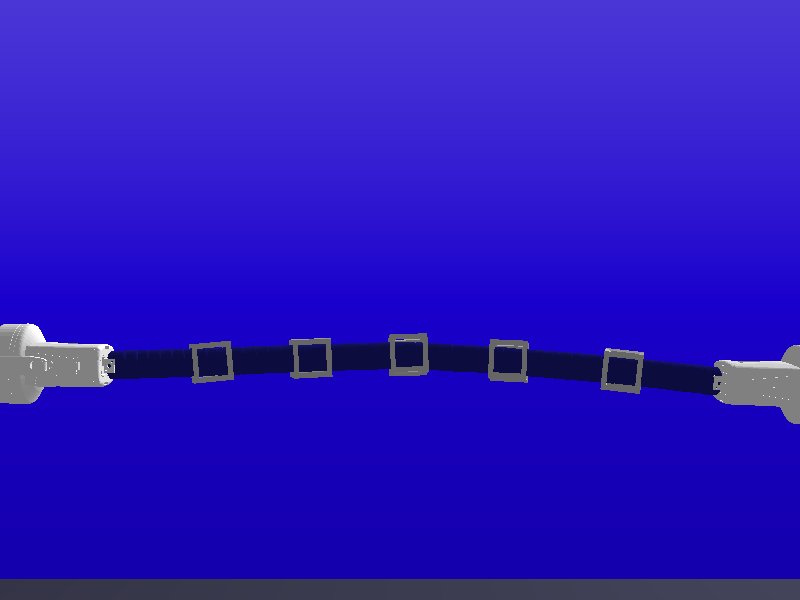

In [5]:
import yaml
import jax.numpy as jnp
from ajx import Transform
from ajx.example_environments.dlo import DLO, DLOSettings, CableParameters
from ajx.simulation import SimulationSettings, Solver
import jax.numpy as jnp
import ajx.math as math
from ajx import Transform


with open("marker_data/real_dlo_marker_data.yaml", "r") as stream:
    data_loaded = yaml.safe_load(stream)

all_marker_transforms = []
for sample_name, marker_pose in data_loaded["marker_poses"].items():
    print(sample_name)
    marker_transform_list = []
    for site_name, pose in marker_pose.items():
        transform = Transform(
            jnp.array(pose["pos"]),
            jnp.array(pose["rot"]),
        )
        marker_transform_list.append(transform)
    marker_transforms = Transform.stack(marker_transform_list)
    all_marker_transforms.append(marker_transforms)

timestep = 1/60
gripper_com_to_marker = jnp.array(data_loaded["gripper_com_to_marker"])
env = DLO(
    sim_settings=SimulationSettings(timestep, True, Solver.DENSE_LINEAR),
    env_settings=DLOSettings.create(
        n_segments=50,
        length=data_loaded["length"],
        radius=data_loaded["radius"],
        density=data_loaded["mass"] / ( jnp.pi * (data_loaded["radius"] ** 2) * data_loaded["length"] ),
        pose_estimate_linear_offsets=data_loaded["marker_displacements"],
        gripper1_offset=Transform(gripper_com_to_marker, math.Rotations.unitary),
        gripper2_offset=Transform(-gripper_com_to_marker, math.Rotations.unitary),
        loose_end=False,
    ),
)
env.camera_rot = math.quat_from_axis_angle(jnp.array([0.0, 0.0, 1.0]), jnp.pi)

# Pretend that stiffness is unknown
env_param = env.default_param.tree_replace(src={
    "sparse_param.cable_param.youngs_modulus":  1e4,
    "sparse_param.cable_param.shear_modulus":  1e4,
})

# Set stiffness as tunable
env_param = env_param.replace(
    tangent_restrictions=(
        "sparse_param.cable_param.youngs_modulus",
        "sparse_param.cable_param.shear_modulus",
    )
)

body_transforms = env.convert_marker_transforms_to_body_transforms(
    all_marker_transforms[0]
)
frame_transforms = env.convert_body_transforms_to_frame_transforms(
    env_param, body_transforms
)
state = env.get_state_by_interface_interpolation(
    env_param, [frame_transforms[0], frame_transforms[1], body_transforms]
)
# Code for graphics following scenes/dlo.py or the first example in notebooks/dlo.ipynb

# For example, to visualize the initial state:
from panda3d.core import loadPrcFileData
loadPrcFileData("", "window-type offscreen")
loadPrcFileData("", "win-size 640 480")

from ajx.example_graphics.environment_scene import EnvironmentScene
from ajx.example_graphics.application import Application
from IPython.display import display

# Create scene using YOUR reconstructed state
scene = EnvironmentScene(
    env,
    env_param,
    state,
    show_text=False,
    show_fps=False,
    debug_render=False
)

# Create application (renderer)
if "app" in locals():
    app.destroy()
    del app

app = Application(scene, 60, "default", headless=True)

# Render frame
scene.update_geometry()
img = app.get_headless_frame()

# Display image
display(img)

### Optimization

In [7]:
from ajx.tree_util import tangent_jacfwd
from ajx.definitions import State, GeneralizedVelocity
from ajx.example_environments.dlo import DLOState
target_pose = state.conf
lock_targets = state.lock_targets
start_err = jnp.linalg.norm(state.gvel.data)
n_bodies = env.env_settings.n_segments

def multi_frame_inverse_residual(param):
    residuals = []

    for marker_transforms in all_marker_transforms:

        # Convert markers → bodies
        body_transforms = env.convert_marker_transforms_to_body_transforms(
            marker_transforms
        )

        # Convert bodies → frames
        frame_transforms = env.convert_body_transforms_to_frame_transforms(
            param, body_transforms
        )

        # Reconstruct state
        state = env.get_state_by_interface_interpolation(
            param,
            [frame_transforms[0], frame_transforms[1], body_transforms],
        )

        # Zero velocity assumption
        n_bodies = env.env_settings.n_segments
        gvel = GeneralizedVelocity(jnp.zeros([n_bodies + 6, 6]))

        state = DLOState(state.conf, gvel, state.lock_targets)

        # Compute inverse dynamics residual
        force = env.sim.inverse_dynamics(
            state,
            gvel,
            jnp.zeros([12]),
            param
        )
        #print(jnp.linalg.norm(force))

        residuals.append(force.flatten())

    # Stack everything into ONE vector
    return jnp.concatenate(residuals)

def multi_frame_forward_residual(param):
    residuals = []

    for marker_transforms in all_marker_transforms[:10]:  # start small

        body_transforms = env.convert_marker_transforms_to_body_transforms(
            marker_transforms
        )

        frame_transforms = env.convert_body_transforms_to_frame_transforms(
            param, body_transforms
        )

        state = env.get_state_by_interface_interpolation(
            param,
            [frame_transforms[0], frame_transforms[1], body_transforms],
        )

        n_bodies = env.env_settings.n_segments
        gvel = GeneralizedVelocity(jnp.zeros([n_bodies + 6, 6]))
        state = DLOState(state.conf, gvel, state.lock_targets)

        next_state = env.step_state(
            state,
            jnp.zeros([12]),
            param
        )

        residuals.append(next_state.gvel.data.flatten())

    return jnp.concatenate(residuals)

def forward_dynamics_residual(param):
    gvel = GeneralizedVelocity(jnp.zeros([n_bodies+6, 6]))
    state = DLOState(target_pose, gvel, lock_targets)
    next_state = env.step_state(state, jnp.zeros([12]), param)
    return next_state.gvel.data.flatten()

def inverse_dynamics_residual(param):
    gvel = GeneralizedVelocity(jnp.zeros([n_bodies+6, 6]))
    state = DLOState(target_pose, gvel, lock_targets)
    force = env.sim.inverse_dynamics(state, gvel, jnp.zeros([12]), param)
    return force.flatten()

residual = multi_frame_inverse_residual
jac_r = tangent_jacfwd(residual)

def gauss_newton(x0, n_iter, damping):
    x = x0
    for i in range(n_iter):
        rx = residual(x)
        J = jac_r(x) 

        # Gauss-Newton step: solve (J^T J) delta = -J^T r
        JTJ = J.T @ J + jnp.eye(J.shape[1]) * damping
        JTr = J.T @ rx
        delta = -jnp.linalg.solve(JTJ, JTr)

        x = x.retract(delta)
        print(f"Iter: {i}\t |rx|: {jnp.linalg.norm(rx)}")
    return x, J

# Set stiffness as tunable
env_param = env_param.replace(
    tangent_restrictions=(
        "sparse_param.cable_param.youngs_modulus",
        "sparse_param.cable_param.shear_modulus",
    )
)

# Optimize
solution, Js = gauss_newton(env_param, n_iter=10, damping=0.0)
print(jnp.linalg.cond(Js))

Iter: 0	 |rx|: 2432876.75
Iter: 1	 |rx|: 2432657.0
Iter: 2	 |rx|: 2432657.0
Iter: 3	 |rx|: 2432657.0
Iter: 4	 |rx|: 2432657.0
Iter: 5	 |rx|: 2432657.0
Iter: 6	 |rx|: 2432657.0
Iter: 7	 |rx|: 2432657.0
Iter: 8	 |rx|: 2432657.0
Iter: 9	 |rx|: 2432657.0
101899.4


### Sweep over Young's modulus

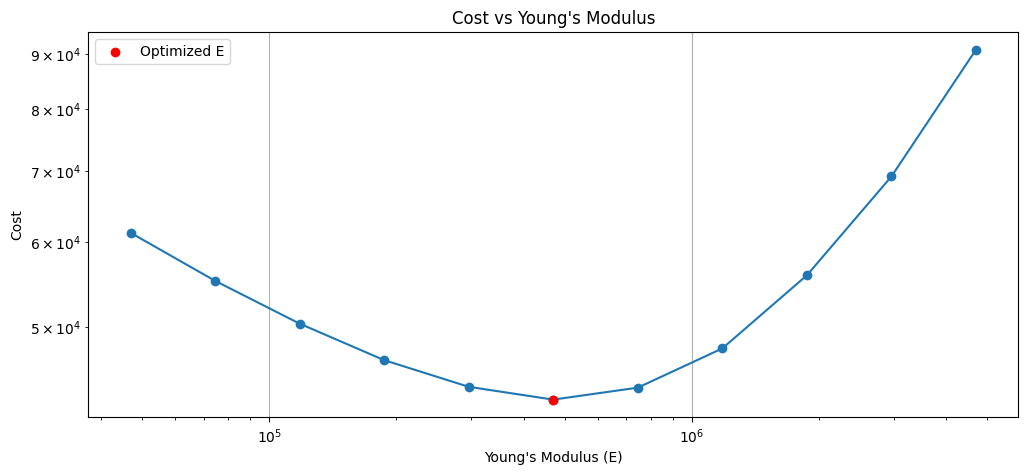

In [19]:
def cost(param):
    r = residual(param)
    return jnp.sum(r**2)

opt_param = solution

# Extract optimized parameter
E_opt = opt_param.sparse_param.cable_param.youngs_modulus

# Sweep over Young's modulus
E_values = jnp.logspace(jnp.log10(E_opt) - 1,
                       jnp.log10(E_opt) + 1,
                       11)

costs_E = []

for E in E_values:
    test_param = opt_param.tree_replace(src={
        "sparse_param.cable_param.youngs_modulus": E
    })
    
    c = cost(test_param)
    costs_E.append(c)


# Plot the cost vs Young's modulus
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(E_values, costs_E, marker='o')
plt.scatter([E_opt], [cost(opt_param)], color='red', label='Optimized E', zorder=5)
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Young's Modulus (E)")
plt.ylabel("Cost")
plt.title("Cost vs Young's Modulus")
plt.grid(True)

plt.savefig("cost_vs_E.pdf", format="pdf")

### Sweep over shear modulus

In [ ]:
# Extract optimized parameter
G_opt = opt_param.sparse_param.cable_param.shear_modulus

# Sweep over Shear modulus
G_values = jnp.logspace(jnp.log10(G_opt) - 1,
                       jnp.log10(G_opt) + 1,
                       11)

costs_G = []

for G in G_values:
    test_param = opt_param.tree_replace(src={
        "sparse_param.cable_param.shear_modulus": G
    })
    
    c = cost(test_param)
    costs_G.append(c)

# Plot the cost vs Young's modulus
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(G_values, costs_G, marker='o')
plt.scatter([G_opt], [cost(opt_param)], color='red', label='Optimized E', zorder=5)
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel("shear Modulus (E)")
plt.ylabel("Cost")
plt.title("Cost vs shear Modulus")
plt.grid(True)

plt.savefig("cost_vs_G.pdf", format="pdf")

NameError: name 'opt_param' is not defined